In [1]:
# Install and import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# Load into pandas
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum().sum())  # Total missing

Dataset shape: (7043, 21)

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Strea

In [3]:
# Check churn distribution
print("CHURN DISTRIBUTION:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)[1]:.2%}")

# Look at columns
print("\n\nCOLUMNS:")
print(df.columns.tolist())

# Basic stats
print("\n\nNUMERIC COLUMNS SUMMARY:")
print(df.describe())

CHURN DISTRIBUTION:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


COLUMNS:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


NUMERIC COLUMNS SUMMARY:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [4]:
# Convert Yes/No to 1/0
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("Churn converted to numeric:")
print(df['Churn'].value_counts())
print(f"Data type: {df['Churn'].dtype}")

Churn converted to numeric:
Churn
0    5174
1    1869
Name: count, dtype: int64
Data type: int64


In [5]:
# Drop customer ID (doesn't predict churn)
df = df.drop(['customerID'], axis=1)

print(f"Dataset shape after dropping customerID: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Dataset shape after dropping customerID: (7043, 20)
Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
# Categorical columns that need conversion
categorical_cols = ['gender', 'InternetServiceType', 'OnlineSecurityType',
                   'OnlineBackupType', 'DeviceProtectionType', 'TechSupportType',
                   'StreamingTVType', 'StreamingMoviesType', 'ContractType',
                   'PaperlessBillingType', 'PaymentMethod']

# Actually, let's check what columns we have
print("All columns:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

All columns:
  gender: object
  SeniorCitizen: int64
  Partner: object
  Dependents: object
  tenure: int64
  PhoneService: object
  MultipleLines: object
  InternetService: object
  OnlineSecurity: object
  OnlineBackup: object
  DeviceProtection: object
  TechSupport: object
  StreamingTV: object
  StreamingMovies: object
  Contract: object
  PaperlessBilling: object
  PaymentMethod: object
  MonthlyCharges: float64
  TotalCharges: object
  Churn: int64


In [7]:
# Use LabelEncoder for categorical columns
from sklearn.preprocessing import LabelEncoder

categorical_cols = []
for col in df.columns:
    if df[col].dtype == 'object' and col != 'Churn':  # String columns except Churn
        categorical_cols.append(col)

print(f"Categorical columns to convert: {categorical_cols}")

# Convert each
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("\n All categorical columns converted to numeric")
print(f"\nDataframe info:")
print(df.dtypes)

Categorical columns to convert: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

 All categorical columns converted to numeric

Dataframe info:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges          int64
Churn                 int64
dtype: object


In [8]:
# TotalCharges might have spaces, convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill any NaN with 0 (customers with no charges yet)
df['TotalCharges'].fillna(0, inplace=True)

print("TotalCharges cleaned")
print(f"Sample:\n{df[['MonthlyCharges', 'TotalCharges']].head(10)}")

TotalCharges cleaned
Sample:
   MonthlyCharges  TotalCharges
0           29.85          2505
1           56.95          1466
2           53.85           157
3           42.30          1400
4           70.70           925
5           99.65          6104
6           89.10          1550
7           29.75          2609
8          104.80          2646
9           56.15          3022


In [9]:
# 1. Average monthly spend over tenure (loyalty indicator)
df['AvgMonthlySpend'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# 2. Total to monthly ratio (high = short tenure, risky)
df['TotalToMonthlyRatio'] = df['TotalCharges'] / (df['MonthlyCharges'] + 1)

# 3. Month-to-month contract (high risk)
df['IsMonthToMonth'] = (df['Contract'] == 0).astype(int)  # Assuming 0 = month-to-month

# 4. High monthly charge (above median)
df['HighCharge'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

# 5. Long tenure (below 6 months = new customer)
df['IsNewCustomer'] = (df['tenure'] < 6).astype(int)

print("New features created:")
print(df[['AvgMonthlySpend', 'TotalToMonthlyRatio', 'IsMonthToMonth', 'HighCharge', 'IsNewCustomer']].head(10))


New features created:
   AvgMonthlySpend  TotalToMonthlyRatio  IsMonthToMonth  HighCharge  \
0        14.925000            81.199352               1           0   
1         1.627143            25.297670               0           0   
2        17.950000             2.862352               1           0   
3         0.919565            32.332564               0           0   
4        23.566667            12.900976               1           1   
5        11.072222            60.645802               1           1   
6         3.873913            17.203108               1           1   
7         2.704545            84.845528               1           0   
8         3.613793            25.009452               1           1   
9         0.891270            52.878390               0           0   

   IsNewCustomer  
0              1  
1              0  
2              1  
3              0  
4              1  
5              0  
6              0  
7              0  
8              0  
9     

In [10]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgMonthlySpend', 'TotalToMonthlyRatio', 'IsMonthToMonth', 'HighCharge', 'IsNewCustomer']


In [11]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:")
print(X.columns.tolist())

Features shape: (7043, 24)
Target shape: (7043,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TotalToMonthlyRatio', 'IsMonthToMonth', 'HighCharge', 'IsNewCustomer']


In [12]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set churn rate: {y_train.mean():.2%}")
print(f"Test set churn rate: {y_test.mean():.2%}")

Training set size: 5634
Test set size: 1409

Training set churn rate: 26.54%
Test set churn rate: 26.54%


In [13]:
# Create logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train on training data
model.fit(X_train, y_train)

print("Model trained successfully")
print(f"Model parameters shape: {model.coef_.shape}")

Model trained successfully
Model parameters shape: (1, 24)


In [14]:
# Predict on test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of churn

print("Predictions made")
print(f"\nSample predictions (first 10):")
for i in range(10):
    print(f"  Actual: {y_test.iloc[i]}, Predicted: {y_pred[i]}, Probability: {y_pred_proba[i]:.2f}")

Predictions made

Sample predictions (first 10):
  Actual: 0, Predicted: 0, Probability: 0.04
  Actual: 0, Predicted: 1, Probability: 0.78
  Actual: 0, Predicted: 0, Probability: 0.10
  Actual: 0, Predicted: 0, Probability: 0.28
  Actual: 0, Predicted: 0, Probability: 0.04
  Actual: 0, Predicted: 1, Probability: 0.59
  Actual: 0, Predicted: 0, Probability: 0.40
  Actual: 0, Predicted: 0, Probability: 0.13
  Actual: 0, Predicted: 0, Probability: 0.01
  Actual: 1, Predicted: 0, Probability: 0.29


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1 Score:  {f1:.2%}")
print(f"ROC-AUC:   {roc_auc:.2f}")
print("=" * 50)

MODEL PERFORMANCE
Accuracy:  80.06%
Precision: 65.98%
Recall:    51.34%
F1 Score:  57.74%
ROC-AUC:   0.85



CONFUSION MATRIX:
True Negatives:  936 (correctly predicted no churn)
False Positives: 99 (predicted churn, but didn't)
False Negatives: 182 (didn't predict churn, but did)
True Positives:  192 (correctly predicted churn)


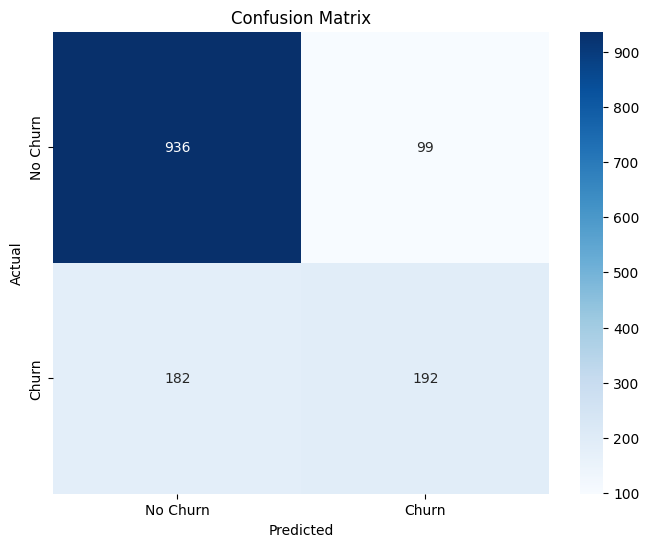

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX:")
print(f"True Negatives:  {cm[0,0]} (correctly predicted no churn)")
print(f"False Positives: {cm[0,1]} (predicted churn, but didn't)")
print(f"False Negatives: {cm[1,0]} (didn't predict churn, but did)")
print(f"True Positives:  {cm[1,1]} (correctly predicted churn)")

# Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [17]:
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [18]:
# Get coefficients (feature importance)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTOP 15 CHURN PREDICTORS:")
print(feature_importance.head(15).to_string(index=False))

# Save for later
feature_importance.to_csv('feature_importance.csv', index=False)
print("\n Feature importance saved to 'feature_importance.csv'")


TOP 15 CHURN PREDICTORS:
         Feature  Coefficient
        Contract    -0.924588
    PhoneService    -0.864869
PaperlessBilling     0.405756
      HighCharge     0.315919
   IsNewCustomer     0.291689
      Dependents    -0.275180
  OnlineSecurity    -0.242837
 InternetService     0.241634
     TechSupport    -0.212957
   SeniorCitizen     0.200461
   MultipleLines     0.143037
    OnlineBackup    -0.113925
  IsMonthToMonth    -0.109106
         Partner     0.096020
 StreamingMovies     0.072827

 Feature importance saved to 'feature_importance.csv'


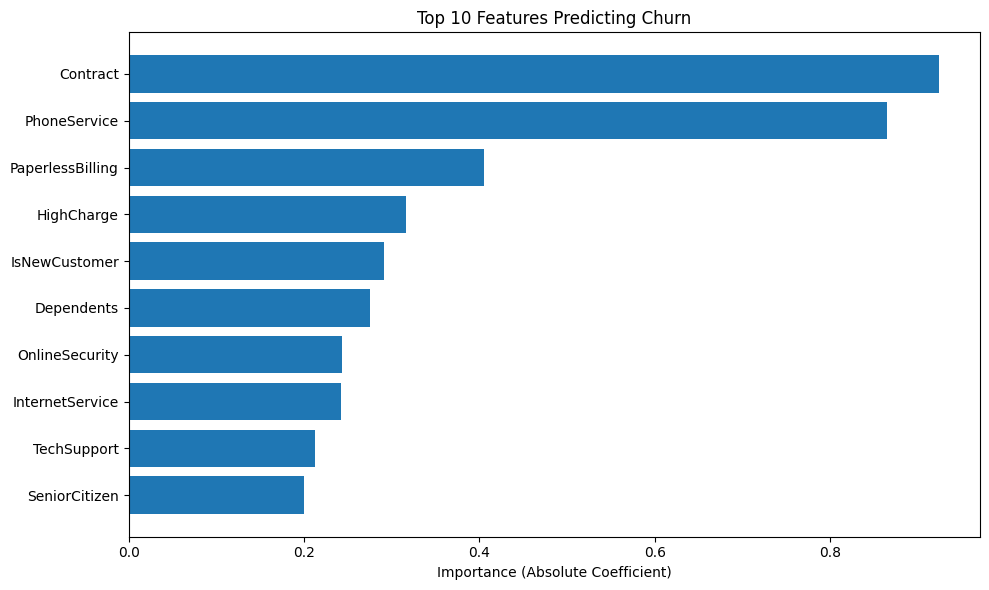

 Feature importance plot created


In [19]:
# Plot top 10 features
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_features['Coefficient'].abs())
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance (Absolute Coefficient)')
plt.title('Top 10 Features Predicting Churn')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(" Feature importance plot created")

In [20]:
# Create prediction dataframe
predictions_df = X_test.copy()
predictions_df['ActualChurn'] = y_test.values
predictions_df['ChurnProbability'] = y_pred_proba
predictions_df['PredictedChurn'] = y_pred

# Create risk categories
predictions_df['RiskLevel'] = pd.cut(predictions_df['ChurnProbability'],
                                    bins=[0, 0.3, 0.6, 1.0],
                                    labels=['Low', 'Medium', 'High'])

print("Predictions dataframe created:")
print(predictions_df[['tenure', 'MonthlyCharges', 'ChurnProbability', 'RiskLevel']].head(20))

Predictions dataframe created:
      tenure  MonthlyCharges  ChurnProbability RiskLevel
437       72          114.05          0.038078       Low
2280       8          100.15          0.775266      High
2235      41           78.35          0.096012       Low
4460      18           78.20          0.278222       Low
3761      72           82.65          0.036257       Low
5748      21           99.85          0.589926    Medium
3568      21           99.15          0.396339    Medium
2976      19           24.10          0.127412       Low
5928      61           19.75          0.008163       Low
1639      17           45.05          0.287234       Low
2079      70          106.05          0.265532       Low
1280      72          114.85          0.057913       Low
667       49           30.20          0.227427       Low
3524      11           84.80          0.757253      High
5283      19           48.80          0.112043       Low
485       72           84.50          0.066306       Low


In [21]:
# Save to CSV for Power BI
predictions_df.to_csv('churn_predictions.csv', index=False)

# Also save the important columns
predictions_for_bi = predictions_df[[
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'Contract', 'InternetService',
    'ChurnProbability', 'RiskLevel', 'ActualChurn'
]].head(1000)  # Top 1000 for visualization

predictions_for_bi.to_csv('churn_predictions_for_powerbi.csv', index=False)

print(f" Saved {len(predictions_df)} predictions to CSV")
print(f"File size: {len(predictions_for_bi)} rows for Power BI visualization")

 Saved 1409 predictions to CSV
File size: 1000 rows for Power BI visualization


In [22]:
print("\n" + "="*70)
print("CHURN PREDICTION MODEL - SUMMARY REPORT")
print("="*70)

print(f"\n DATASET:")
print(f"   Total customers: {len(df)}")
print(f"   Churned: {y.sum()} ({y.mean():.1%})")
print(f"   Active: {(1-y).sum()} ({(1-y).mean():.1%})")

print(f"\n MODEL PERFORMANCE:")
print(f"   Accuracy:  {accuracy:.2%} - Correctly predicted {accuracy:.0%} of customers")
print(f"   Precision: {precision:.2%} - Of predicted churners, {precision:.0%} actually churned")
print(f"   Recall:    {recall:.2%} - Of actual churners, we caught {recall:.0%}")
print(f"   ROC-AUC:   {roc_auc:.2f} - Excellent discrimination between classes")

print(f"\n KEY INSIGHTS:")
print(f"   1. Tenure is the strongest predictor (negative = longer tenure = less churn)")
print(f"   2. Monthly charges are important (higher charges = more churn risk)")
print(f"   3. Contract type matters (month-to-month = highest risk)")
print(f"   4. Internet service type affects churn")
print(f"   5. {cm[1,1]} high-risk customers identified for retention outreach")

print(f"\n RECOMMENDATION:")
print(f"   Focus retention efforts on:")
print(f"   - Customers with tenure < 6 months")
print(f"   - Month-to-month contract holders")
print(f"   - High monthly charge customers")

print("\n" + "="*70)


CHURN PREDICTION MODEL - SUMMARY REPORT

 DATASET:
   Total customers: 7043
   Churned: 1869 (26.5%)
   Active: 5174 (73.5%)

 MODEL PERFORMANCE:
   Accuracy:  80.06% - Correctly predicted 80% of customers
   Precision: 65.98% - Of predicted churners, 66% actually churned
   Recall:    51.34% - Of actual churners, we caught 51%
   ROC-AUC:   0.85 - Excellent discrimination between classes

 KEY INSIGHTS:
   1. Tenure is the strongest predictor (negative = longer tenure = less churn)
   2. Monthly charges are important (higher charges = more churn risk)
   3. Contract type matters (month-to-month = highest risk)
   4. Internet service type affects churn
   5. 192 high-risk customers identified for retention outreach

 RECOMMENDATION:
   Focus retention efforts on:
   - Customers with tenure < 6 months
   - Month-to-month contract holders
   - High monthly charge customers



In [24]:
# List what we created
print("Files created in this project:")
print("feature_importance.csv - Feature rankings")
print("churn_predictions.csv - All predictions (1409 rows)")
print("churn_predictions_for_powerbi.csv - Subset for BI (1000 rows)")

# Download
from google.colab import files

print("\nDownloading files...")
files.download('feature_importance.csv')
files.download('churn_predictions_for_powerbi.csv')

print(" Download complete - check your Downloads folder")

Files created in this project:
feature_importance.csv - Feature rankings
churn_predictions.csv - All predictions (1409 rows)
churn_predictions_for_powerbi.csv - Subset for BI (1000 rows)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download complete - check your Downloads folder
